In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-11-11 11:19:56.257069: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-11 11:19:56.257293: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [2]:
def lR_to_l(adata, mapper={'leiden_R': 'leiden'}):
    for current_col_name in mapper:
        new_col_name = mapper[current_col_name]
        current_col = adata.obs[current_col_name].copy()
        adata.obs.drop(columns=current_col_name)
        adata.obs[new_col_name] = current_col
    return

def reset_colors(adata, key='leiden', use_plt=True):
    if use_plt:
        try:
            del(adata.uns['plt']['color'][key])
        except:
            pass
    else:
        try:
            del(adata.uns['%s_colors' % key])
        except:
            pass
    return

def relabel_clusts(adata, key='leiden'):
    try:
        adata.obs[key].cat
    except AttributeError:
        adata.obs[key] = adata.obs[key].astype('category')
        
    cats = adata.obs[key].cat.categories
    new_cats = [str(i) for i in range(len(cats))]
    adata.obs[key] = adata.obs[key].map(dict(zip(cats, new_cats)))
    adata.obs[key] = adata.obs[key].astype('category')
    
    reset_colors(adata, key=key)
    
    return

def clean_leiden(adata):
    lR_to_l(adata)
    relabel_clusts(adata)

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
%%capture

mdata = mu.read_10x_h5(
    '/ix1/ylee/kor11/cellranger/LupusNov6/LupusNov6/outs/filtered_feature_bc_matrix.h5', 
)

mdata_raw = mu.read_10x_h5(
    '/ix1/ylee/kor11/cellranger/LupusNov6/LupusNov6/outs/raw_feature_bc_matrix.h5', 
)

mdata_raw.var_names_make_unique()
mdata.var_names_make_unique()

In [5]:
mdata

MuData object with n_obs × n_vars = 5877 × 34016
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	5877 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	5877 x 320
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [6]:
mdata_raw

MuData object with n_obs × n_vars = 1577495 × 34016
  var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
  2 modalities
    rna:	1577495 x 33696
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    prot:	1577495 x 320
      var:	'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [18]:
mdata_raw['prot'].var_names

Index(['sbc1', 'sbc2', 'sbc3', 'sbc4', 'sbc5', 'sbc6', 'sbc7', 'sbc8', 'sbc9',
       'sbc10',
       ...
       'Ms.CD186', 'Ms.CD159a', 'Ms.Ly108', 'Ms.CD160', 'Ms.CD85k', 'Ms.CD51',
       'Ms.CD94', 'Ms.CD205', 'Ms.CD155', 'MsRt.CD81'],
      dtype='object', length=320)

In [7]:
mdata_raw['rna'].obs["log10umi"] = np.array(np.log10(mdata_raw['rna'].X.sum(axis=1) + 1)).reshape(-1)
filtered_prot = mdata_raw['prot'][:, ~mdata_raw['prot'].var_names.str.contains('Sample')]
mdata_raw.mod['prot'] = filtered_prot
filtered_prot = mdata['prot'][:, ~mdata['prot'].var_names.str.contains('Sample')]
mdata.mod['prot'] = filtered_prot

In [8]:
isotypes = mdata_raw['prot'].var_names[mdata_raw['prot'].var_names.str.contains('Isotype')].tolist()
isotypes

['Isotype_MOPC.21',
 'Isotype_MOPC.173',
 'Isotype_MPC.11',
 'Isotype_RTK4530',
 'Isotype_RTK2071',
 'Isotype_G0114F7',
 'Isotype_RTK2758',
 'Isotype_RTK4174',
 'Isotype_HTK888']

In [9]:
prot = mdata.mod['prot']
prot

View of AnnData object with n_obs × n_vars = 5877 × 320
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [10]:
from muon import prot as pt

In [11]:
prot.layers['counts'] = prot.X
pt.pp.dsb(
    mdata, 
    mdata_raw, 
    # empty_counts_range=(1.5, 2.8), 
    isotype_controls=isotypes, 
    random_state=1
)

In [12]:
mdata['prot']

AnnData object with n_obs × n_vars = 5877 × 320
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    layers: 'counts'

In [13]:
protein_names = {
    'Ms.CD4': 'Cd4',
    'Ms.CD8a': 'Cd8a',
    'Ms.CD366': 'Havcr2',
    'Ms.CD279': 'Pdcd1',
    'Ms.Ly.6C': 'Ly6c1',
    'HuMs.CD11b': 'Itgam',
    'Ms.Ly.6G': 'Ly6g',
    'HuMs.CD49f': 'Itga6',
    'HuMs.CD44': 'Cd44',
    'Ms.CD54': 'Icam1',
    'Ms.CD90.2': 'Thy1',
    'Ms.CD73': 'Nt5e',
    'Ms.CD49d': 'Itga4',
    'Ms.CD200': 'Cd200',
    'Ms.CD19': 'Cd19',
    'Ms.CD45': 'Ptprc',
    'Ms.CD25': 'Il2ra',
    'HuMs.CD45R_B220': 'Ptprc',
    'Ms.CD115': 'Csf1r',
    'Ms.CD11c': 'Itgax',
    'Ms.CD21_CD35': 'Cr2',
    'Ms.CD23': 'Fcer2a',
    'Ms.CD43': 'Spn',
    'Ms.CD5': 'Cd5',
    'Ms.CD62L': 'Sell',
    'Ms.CD93': 'Cd93',
    'Ms.F4_80': 'Adgre1',
    'Ms.FceRIa': 'Fcer1a',
    'Ms.I.A_I.E': 'H2-Ab1',
    'Ms.NK.1.1': 'Klrb1c',
    'Ms.Siglec_H': 'Siglech',
    'Ms.TCR.Bchain': 'Tcrb',
    'Ms.TCR.RD_GL3': 'Tcrd',
    'Ms.TER.119': 'Ly76',
    'Ms.Ly.6A_E': 'Ly6a',
    'Ms.CD45.2': 'Ptprc',
    'HuMsRt.CD278': 'Icos',
    'Ms.CD3': 'Cd3e',
    'Ms.CD274': 'Cd274',
    'HuMsRt.CD27': 'Cd27',
    'Ms.CD20': 'Ms4a1',
    'Ms.CD357': 'Tnfrsf18',
    'Ms.CD137': 'Tnfrsf9',
    'Ms.CD134': 'Tnfrsf4',
    'Ms.CD69': 'Cd69',
    'Ms.CD127': 'Il7r',
    'Ms.CD86': 'Cd86',
    'Ms.CD103': 'Itgae',
    'Ms.CD150': 'Slamf1',
    'Ms.CD24': 'Cd24a',
    'HuMs.integrin.b7': 'Itgb7',
    'Ms.CD106': 'Vcam1',
    'Ms.CD183': 'Cxcr3',
    'Ms.CD8b': 'Cd8b1',
    'Ms.TCR.Vb8.1_8.2': 'Trbv13',
    'HuMs.KLRG1': 'Klrg1',
    'Ms.TCR.Vb5.1_5.2': 'Trbv5',
    'Ms.CD223': 'Lag3',
    'Ms.CD163': 'Cd163',
    'Ms.CD49b': 'Itga2',
    'Ms.CD172a': 'Sirpa',
    'Ms.CD48': 'Cd48',
    'Ms.CD170': 'Siglec5',
    'Ms.CD169': 'Siglec1',
    'Ms.CD71': 'Tfrc',
    'Ms.CD41': 'Itga2b',
    'Ms.CD304': 'Nrp1',
    'Ms.CD38': 'Cd38',
    'Ms.CD55': 'Cd55',
    'Ms.CD63': 'Cd63',
    'Ms.CD301b': 'Mgl2',
    'Ms.Tim.4': 'Timd4',
    'MsRt.CD29': 'Itgb1',
    'Ms.IgD': 'Ighd',
    'Ms.CD11a': 'Itgal',
    'Ms.CD200R': 'Cd200r1',
    'Ms.CCR3': 'Ccr3',
    'Ms.CD138': 'Sdc1',
    'Ms.CD317': 'Bst2',
    'Ms.CD9': 'Cd9',
    'Ms.CD371': 'Clec12a',
    'Ms.CD22': 'Cd22',
    'Ms.Ly49H': 'Klra8',
    'Ms.Ly49D': 'Klra4',
    'Ms.Ly.49A': 'Klra1',
    'Ms.CD185': 'Cxcr5',
    'Ms.CD49a': 'Itga1',
    'Ms.CD1d': 'Cd1d1',
    'Ms.CD226_10E5': 'Cd226',
    'Ms.CD272': 'Btla',
    'Ms.CD2': 'Cd2',
    'Ms.CD120b': 'Tnfrsf1b',
    'Ms.CD40': 'Cd40',
    'Ms.CD31': 'Pecam1',
    'Ms.CD107a': 'Lamp1',
    'Ms.CD182': 'Cxcr2',
    'MsRt.CD61': 'Itgb3',
    'Ms.VISTA': 'Vsir',
    'Ms.CD186': 'Cxcr6',
    'Ms.Ly108': 'Slamf6',
    'Ms.TCR.Va2': 'Trav14',
    'Ms.TCR.Va8.3_KT50': 'Trav8',
    'Ms.TCR.GD_UC7': 'Tcrg',
    'Ms.CD98': 'Slc3a2',
    'Ms.CD160': 'Cd160',
    'Ms.CD51': 'Itgav',
    'Ms.CD94': 'Klrd1',
    'Ms.CD205': 'Ly75',
    'Ms.CD155': 'Pvr',
    'Ms.CD88': 'C5ar1',
    'Ms.FR4': 'Folr4',
    'Ms.CD45RB': 'Ptprc',
    'MsRt.CD81': 'Cd81'
}

In [14]:
import scanpy as sc
import matplotlib.pyplot as plt

rna = mdata['rna'].copy()
prot = mdata['prot'].copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)

In [15]:
sc.pp.pca(rna)
sc.pp.neighbors(rna)

In [16]:
sc.tl.umap(rna, min_dist=0.1, spread=0.1)
prot.obsm['X_umap'] = rna.obsm['X_umap']
prot.X = prot.X.clip(0)

In [17]:
# prot.obs['cell_type'] = adata.obs['cell_type'].copy()

NameError: name 'adata' is not defined

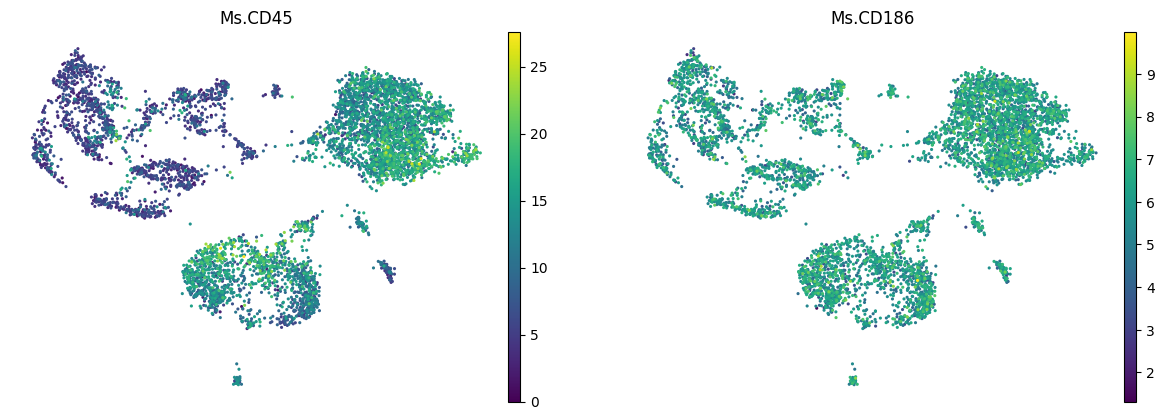

In [23]:
sc.pl.umap(prot, color=['Ms.CD45', 'Ms.CD186'], frameon=False)
# 'cell_type'

In [26]:
adata = adata = sc.read_10x_h5('/ix1/ylee/kor11/cellranger/LupusNov6/LupusNov6/outs/filtered_feature_bc_matrix.h5', gex_only=False)
adata.var_names_make_unique()
adata.var.loc[adata.var.gene_ids.str.startswith('sgbc'), "feature_types"] = "Spatial Capture"

sbcs = adata.var_names[adata.var_names.str.contains('sbc')]

In [71]:
rows = [f'sbc{i}' for i in range(1, 42)]
cols = [f'sbc{i}' for i in range(97, 138)]
df = pd.DataFrame(index=rows, columns=cols)
for r in rows:
    for c in cols:
        df.loc[r, c] = f'{r}-{c}'

x = []
y = []

df_adata = adata.to_df()[df.index]
top10 = df_adata.replace(0, np.nan).apply(lambda row: row.nlargest(10).dropna().index.tolist(), axis=1)

x = [
    np.random.choice(choices) if len(choices) >= 1 else None
    for choices in top10
]

df_adata = adata.to_df()[df.columns]
top10 = df_adata.replace(0, np.nan).apply(lambda row: row.nlargest(10).dropna().index.tolist(), axis=1)

y = [
    np.random.choice(choices) if len(choices) >= 1 else None
    for choices in top10
]

len(x), len(y)

(5877, 5877)

In [72]:
xy_raw = pd.DataFrame({'x': x, 'y': y})
xy_raw

,x,y
0,None,sbc100
1,sbc13,None
2,sbc24,sbc136
3,sbc15,sbc113
4,None,sbc124
...,...,...
5872,sbc14,sbc119
5873,None,sbc118
5874,sbc26,sbc136
5875,sbc12,sbc115


In [73]:
import matplotlib.pyplot as plt

# Categorize each row
def categorize(row):
    x_missing = pd.isna(row['x'])
    y_missing = pd.isna(row['y'])
    if not x_missing and not y_missing:
        return "both"
    elif x_missing and not y_missing:
        return "only y"
    elif not x_missing and y_missing:
        return "only x"
    else:
        return "neither"

category_counts = xy_raw.apply(categorize, axis=1).value_counts().reindex(["only x", "only y", "both", "neither"], fill_value=0)

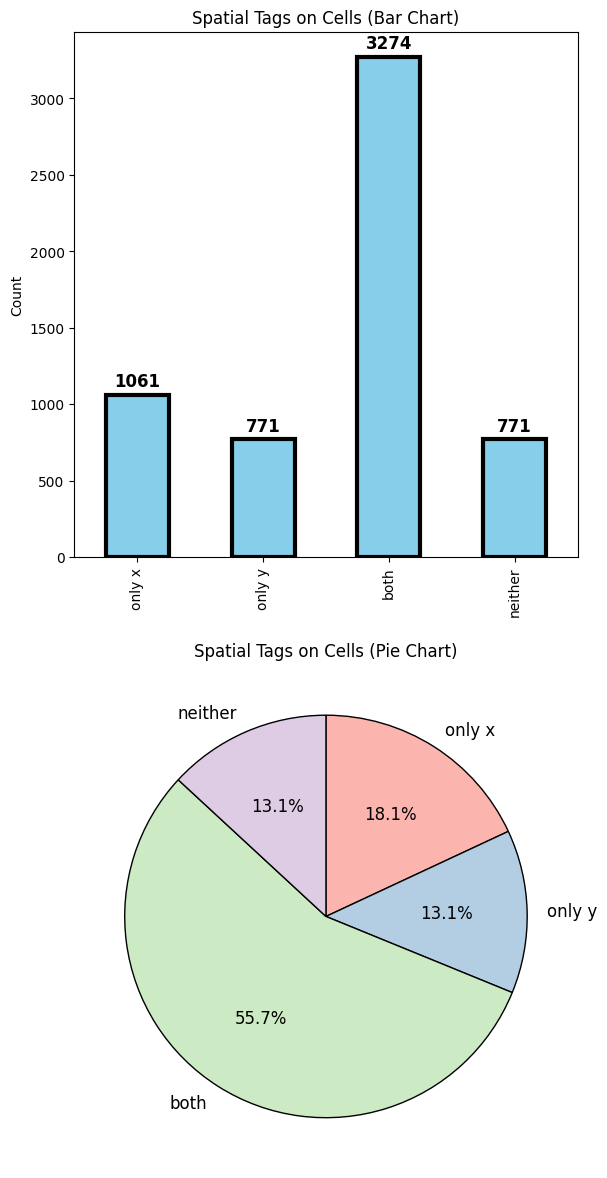

In [74]:
fig, axes = plt.subplots(2, 1, figsize=(6, 12), dpi=100)

# Bar chart (original)
bars = category_counts.plot(kind="bar", linewidth=3, edgecolor='black', ax=axes[0], color='skyblue')
axes[0].set_ylabel("Count")
axes[0].set_title("Spatial Tags on Cells (Bar Chart)")

# Add cell number (count) on each bar
for p in axes[0].patches:
    count = int(p.get_height())
    axes[0].annotate(str(count), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom',
                    fontsize=12, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Pie chart with annotation
labels = category_counts.index.tolist()
sizes = category_counts.values
colors = plt.cm.Pastel1(range(len(sizes)))
wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, autopct='%1.1f%%',
    startangle=90, counterclock=False, colors=colors, wedgeprops=dict(edgecolor='black')
)
for text in texts + autotexts:
    text.set_fontsize(12)
axes[1].set_title("Spatial Tags on Cells (Pie Chart)")

plt.tight_layout()
plt.show()

In [75]:
aa

NameError: name 'aa' is not defined

In [76]:
# def impute_missing_xy(df):
#     """
#     Impute missing x or y in each row, only if exactly one is missing,
#     by filling the missing value with the most likely pairing
#     based on the observed (x, y) pairs in the rest of the dataframe.
#     If there are ties for the most likely pairing, randomly pick one.
#     """
#     from collections import Counter
#     import numpy as np

#     # Calculate co-occurrence frequencies
#     # Only count rows where both x and y are present (neither missing)
#     cooc_counts = df.dropna().value_counts()

#     # Marginals for x and y
#     x_given_y = {}
#     y_given_x = {}
#     # Create mappings to find the most likely y for each x, and vice versa
#     for (row_x, row_y), count in cooc_counts.items():
#         if row_x not in y_given_x:
#             y_given_x[row_x] = Counter()
#         if row_y not in x_given_y:
#             x_given_y[row_y] = Counter()
#         y_given_x[row_x][row_y] += count
#         x_given_y[row_y][row_x] += count

#     # Helper to get the most likely pair, with random tie breaking
#     def most_likely(mapping, key):
#         # mapping: dict of key -> Counter of possible matches
#         if key in mapping and mapping[key]:
#             counter = mapping[key]
#             if not counter:
#                 return None
#             max_count = max(counter.values())
#             candidates = [val for val, cnt in counter.items() if cnt == max_count]
#             if len(candidates) == 1:
#                 return candidates[0]
#             else:
#                 return np.random.choice(candidates)
#         return None

#     df_imputed = df.copy()
#     for idx, row in df.iterrows():
#         # Only impute if exactly one of x or y is missing
#         x_missing = pd.isna(row['x'])
#         y_missing = pd.isna(row['y'])
#         if x_missing and not y_missing:
#             imputed_x = most_likely(x_given_y, row['y'])
#             df_imputed.at[idx, 'x'] = imputed_x
#         elif y_missing and not x_missing:
#             imputed_y = most_likely(y_given_x, row['x'])
#             df_imputed.at[idx, 'y'] = imputed_y
#         # If both missing or neither missing, do nothing
#     return df_imputed

# # Example usage:
# xy_imputed = impute_missing_xy(xy_raw)
# xy_imputed

In [77]:
# heatmap_data = xy_imputed.value_counts().reset_index(
#     name='count').pivot(index='x', columns='y', values='count').fillna(0)
# heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T

# plt.figure(figsize=(10, 10), dpi=300)
# sns.heatmap(
#     np.log10(heatmap_data+1),
#     annot=False,
#     fmt='.1f',
#     cmap='plasma',
#     square=True,
#     cbar=False,
#     annot_kws={"size":5},
#     xticklabels=1,
#     yticklabels=1
# )
# plt.xticks(fontsize=5)
# plt.yticks(fontsize=5)
# plt.xlabel('Plate 1', fontsize=5)
# plt.ylabel('Plate 2', fontsize=5)
# plt.show()

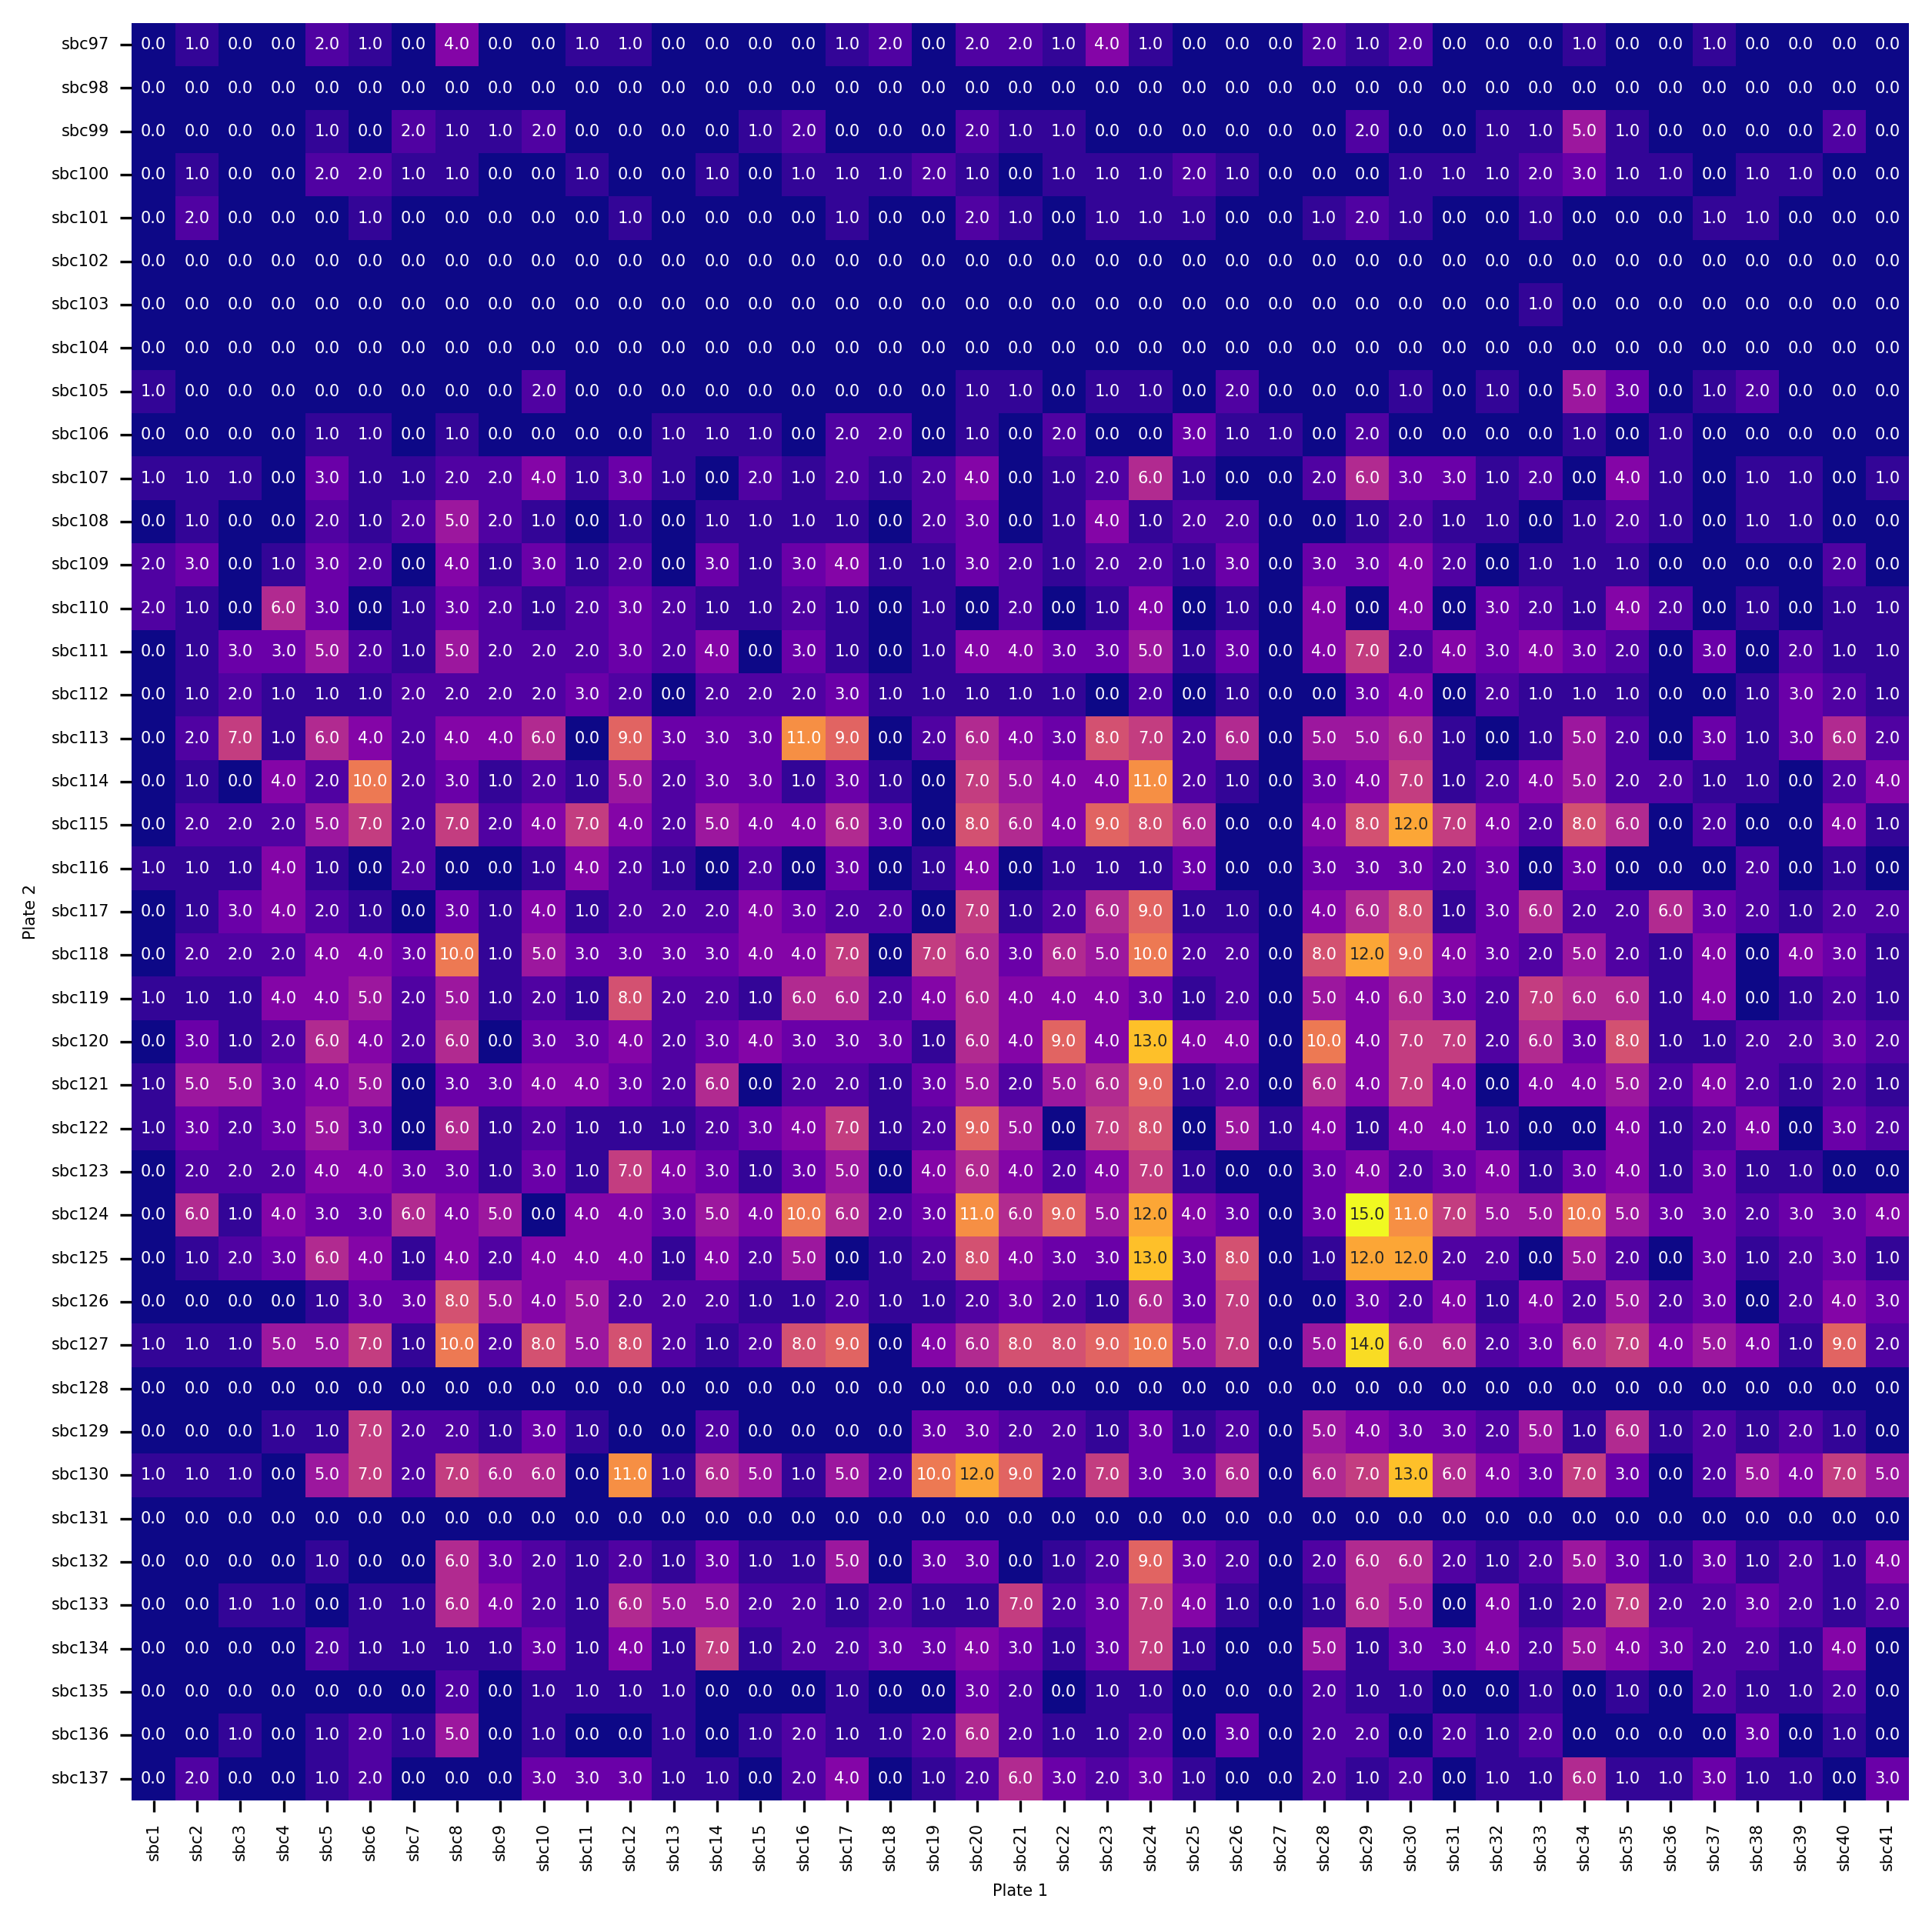

In [78]:
heatmap_data = xy_raw.value_counts().reset_index(
    name='count').pivot(index='x', columns='y', values='count').fillna(0)
heatmap_data = heatmap_data.reindex(df.index).T.reindex(df.columns).T.fillna(0).T

plt.figure(figsize=(10, 10), dpi=300)
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='plasma',
    square=True,
    cbar=False,
    annot_kws={"size":5},
    xticklabels=1,
    yticklabels=1
)
plt.xticks(fontsize=5)
plt.yticks(fontsize=5)
plt.xlabel('Plate 1', fontsize=5)
plt.ylabel('Plate 2', fontsize=5)
plt.savefig('/tmp/heatmap_raw.png', dpi=300)
plt.show()

In [79]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

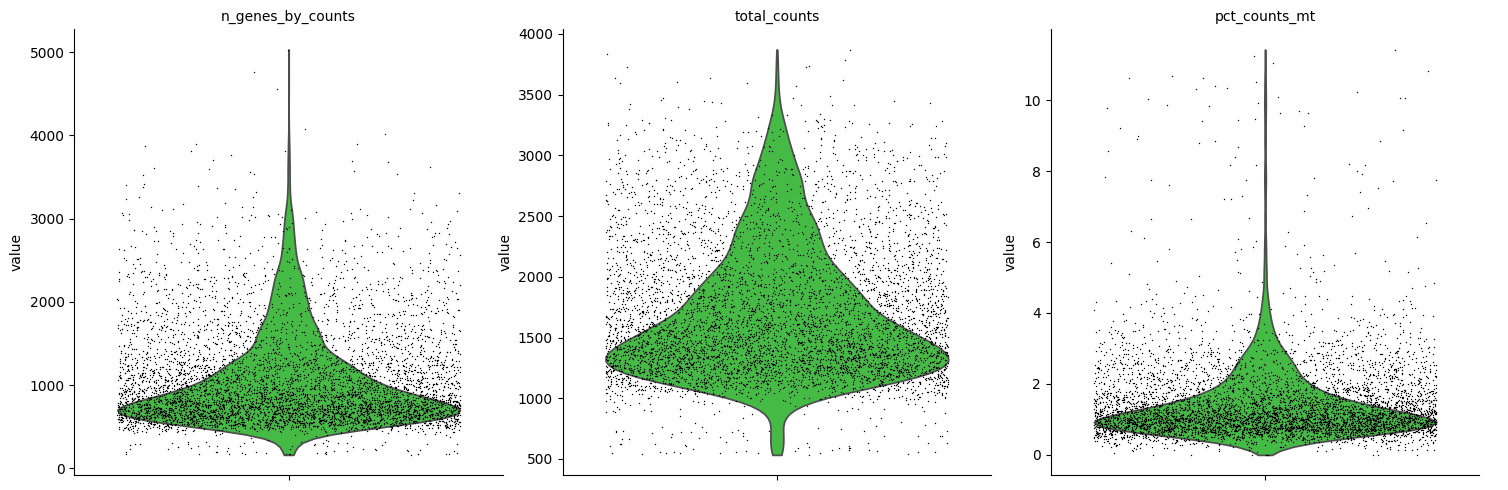

In [80]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    color='limegreen',
)

In [81]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(
    adata, 
    min_mean=0.02, 
    max_mean=4, 
    min_disp=0.5
)
sc.tl.pca(adata, svd_solver='arpack')

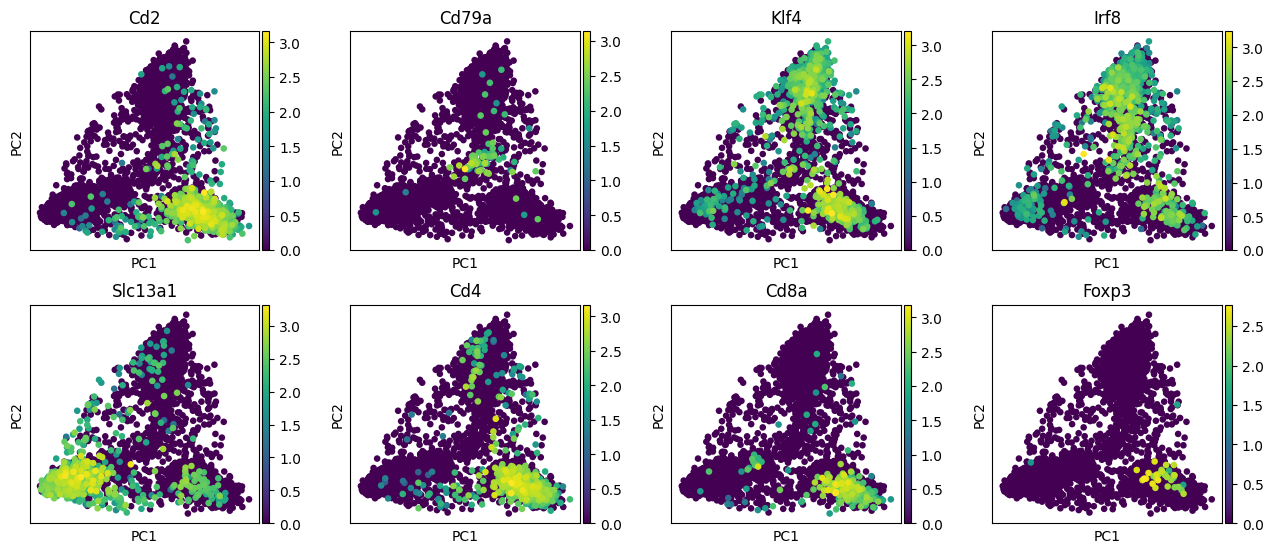

In [82]:
sc.pl.pca(
    adata, 
    color=[
        'Cd2', 
        'Cd79a', 
        'Klf4', 
        'Irf8', 
        'Slc13a1', 
        'Cd4', 
        'Cd8a', 
        'Foxp3'], 
    s=90)

In [83]:
adata = adata[:, ~adata.var_names.str.endswith('Rik')]
adata  = adata[:, ~adata.var_names.str.contains(r'^Hb\w+-\w+$')]
adata = adata[:, ~adata.var_names.str.contains('Hp')]
adata = adata[:, ~adata.var_names.str.startswith('Rp')]
adata = adata[:, ~adata.var_names.str.startswith('n-R5s')]
adata = adata[:, ~adata.var_names.str.startswith('n-R5')]
adata = adata[:, ~adata.var_names.str.startswith('AA')]
adata = adata[:, ~adata.var_names.str.startswith('AB')]
adata = adata[:, ~adata.var_names.str.startswith('AC')]
adata = adata[:, ~adata.var_names.str.startswith('Mir')]

In [84]:
adata.shape, rna.obsm['X_umap'].shape

((5877, 31346), (5877, 2))

In [85]:
adata.obsm['X_umap'] = rna.obsm['X_umap']

In [86]:
adata.obsp = rna.obsp
adata.uns = rna.uns

In [87]:
sc.tl.leiden(
    adata, 
    resolution=0.3, 
    flavor="igraph", 
    n_iterations=2
)

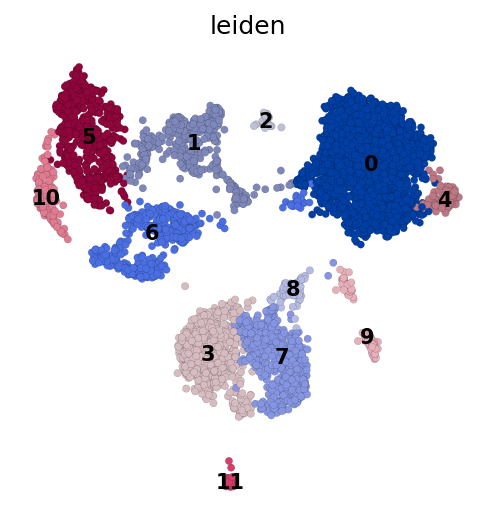

In [88]:
plt.rcParams['figure.figsize'] = (4, 4)
plt.rcParams['figure.dpi'] = 150
sc.pl.umap(
    adata, 
    color=['leiden'], 
    legend_loc='on data', 
    frameon=False, 
    alpha=1, 
    s=50,
    linewidth=0.05, 
    edgecolor='black'
)

In [89]:
sc.tl.leiden(adata, resolution=0.5, flavor="igraph")
sc.tl.leiden(adata, resolution=0.4, restrict_to=('leiden', ['3']), flavor="igraph")
clean_leiden(adata)
sc.tl.leiden(adata, resolution=0.2, restrict_to=('leiden', ['0']), flavor="igraph")
clean_leiden(adata)
sc.tl.leiden(adata, resolution=0.2, restrict_to=('leiden', ['9']), flavor="igraph")
clean_leiden(adata)
sc.tl.leiden(adata, resolution=0.2, restrict_to=('leiden', ['16']), flavor="igraph")
clean_leiden(adata)

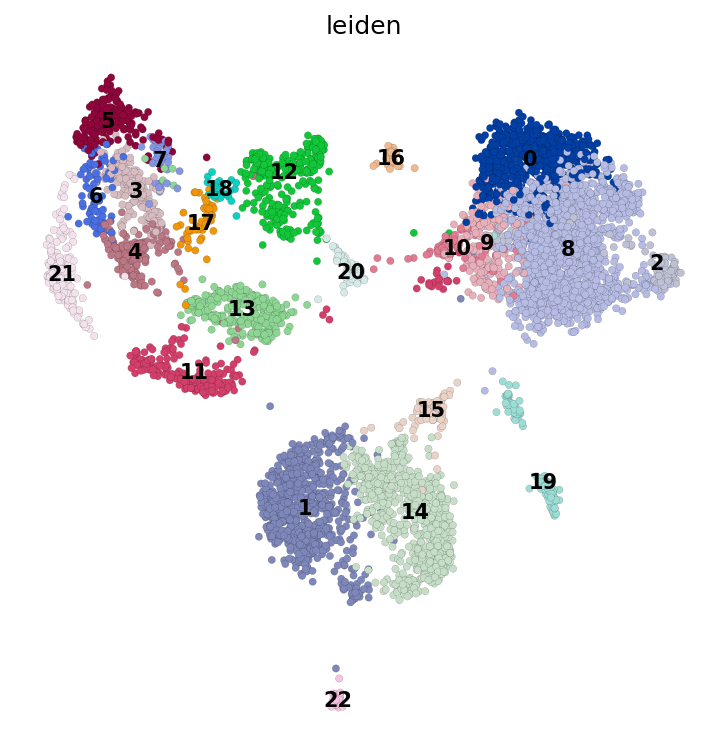

In [90]:
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['figure.dpi'] = 150

sc.pl.umap(
    adata, 
    color=['leiden'], 
    legend_loc='on data', 
    frameon=False, 
    alpha=1, 
    s=50,
    linewidth=0.05, 
    edgecolor='black'
)

In [91]:
plt.rcParams['figure.figsize'] = (4, 4)
plt.rcParams['figure.dpi'] = 200

umap_params = {
    'legend_loc': "on data",
    's': 20,
    'add_outline': True,
    'ncols': 7,
    'frameon': False
}

In [92]:
lupus_markers = {
    'renal_principal_cell': ['Aqp2', 'Aqp3', 'Cdh16', 'Mal', 'Cobll1', 'Pkhd1'],
    'endothelial_cell': ['Cd34', 'Pecam1', 'Ptprb', 'Meis2', 'Flt1', 'Emcn'],
    'NKT_cells': ['Cd247', 'Ccl4', 'Gzma', 'Ccl5', 'Cd8a', 'Fcgr2b'],
    'proximal_tubule_S1S2': ['Slc5a12', 'Slc13a3', 'Slc22a6', 'Slc5a2'],
    'proximal_tubule_S3': ['Slc22a7', 'Mogat1', 'Slc7a13', 'Slc5a8', 'Satb2', 'Slc5a11'],
    'neutrophil': ['S100a9', 'S100a8', 'Ifitm2'],
    'connecting_tubule_epithelial': ['Pcdh7'],
    'monocyte-derived_dendritic_cell': ['Msr1', 'Itgax', 'Csf2ra', 'Cd14', 'Trpm2'],
    'dendritic_cell': ['Itgax', 'Csf2ra', 'Ciita', 'Wdfy4', 'Flt3', 'Cadm1', 'Zbtb46', 'Clec9a'],
    'intercalated_cell': ['Tmem213', 'Atp6v1c2', 'Atp6v0d2'],
    'henle_ascending_limb': ['Casr', 'Slc12a1', 'Umod'],
    'podocytes': ['Wt1', 'Podxl', 'Nphs2'],
    'distal_convoluted_tubule': ['Trpm7', 'Slc8a1', 'Calb1'],
    'collecting_duct': ['Pappa', 'Fxyd4', 'Pde10a']
}

In [93]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 100

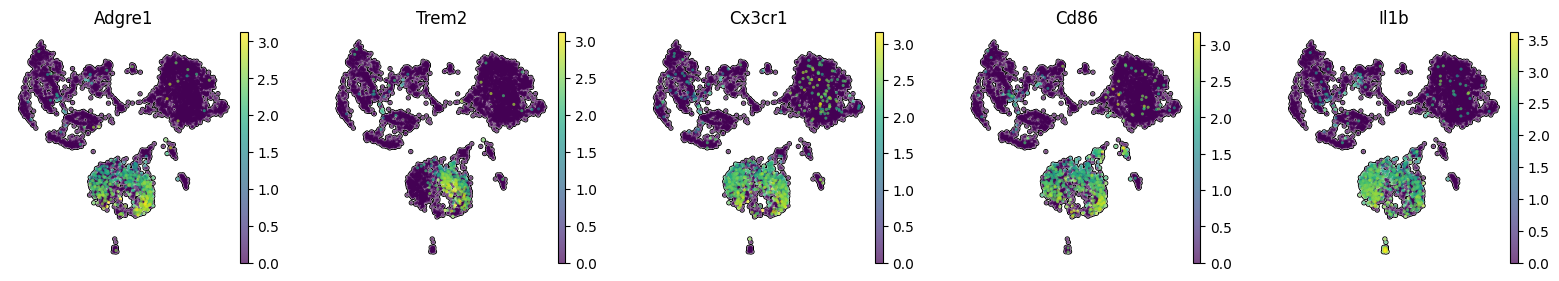

In [94]:
sc.pl.umap(adata, color=['Adgre1', 'Trem2', 'Cx3cr1', 'Cd86', 'Il1b'], **umap_params)

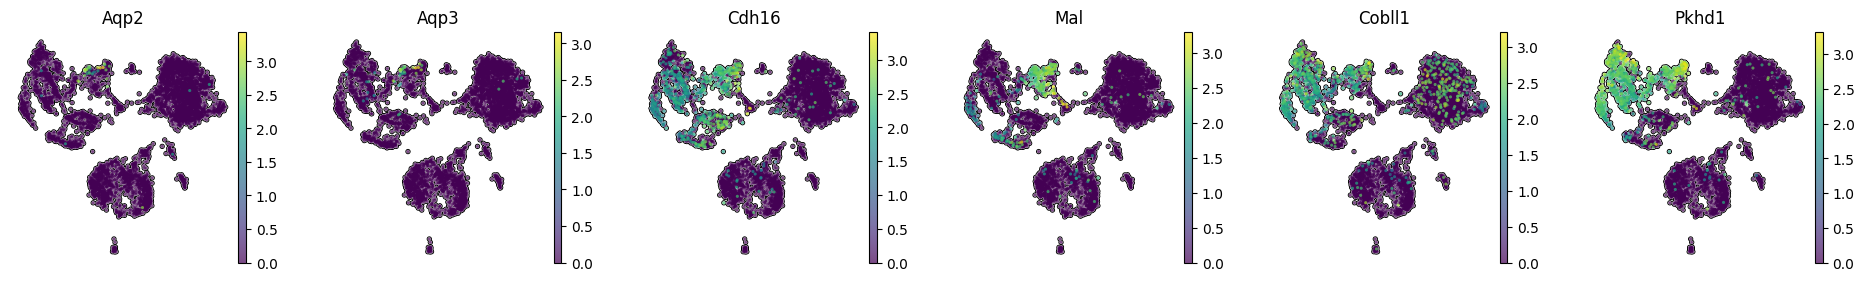

In [95]:
sc.pl.umap(adata, color=lupus_markers['renal_principal_cell'], **umap_params)

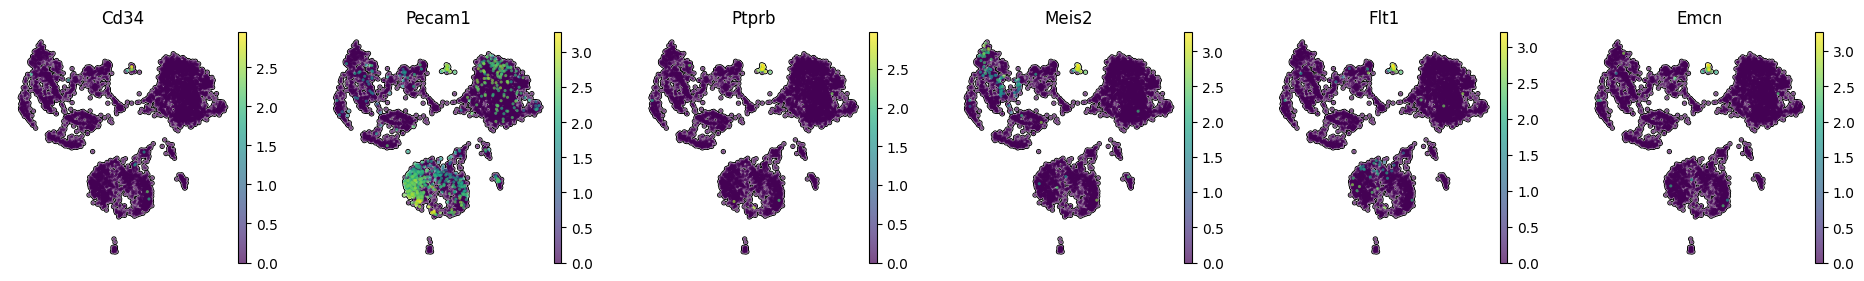

In [96]:
sc.pl.umap(adata, color=lupus_markers['endothelial_cell'], **umap_params)

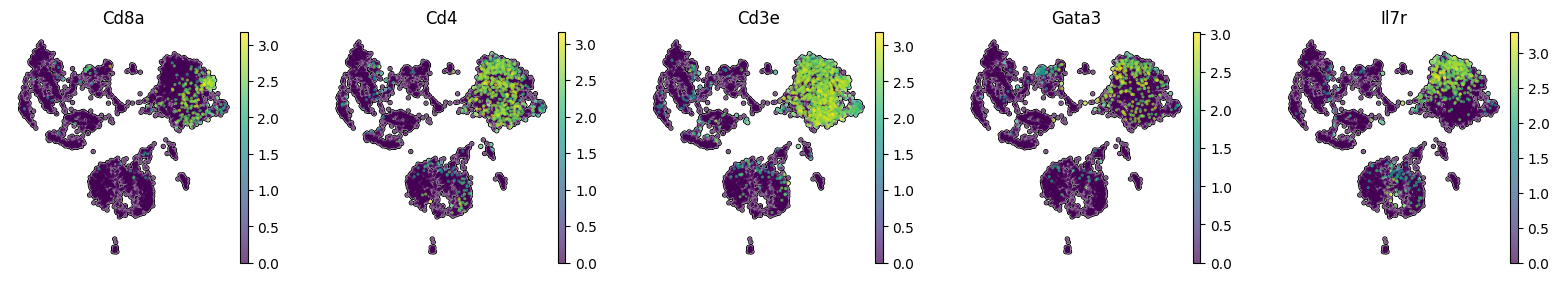

In [97]:
sc.pl.umap(adata, color=['Cd8a', 'Cd4', 'Cd3e', 'Gata3', 'Il7r'], **umap_params)

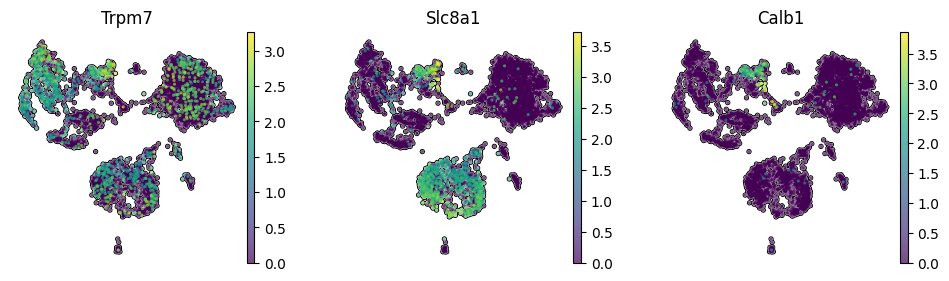

In [98]:
sc.pl.umap(adata, color=lupus_markers['distal_convoluted_tubule'], **umap_params)

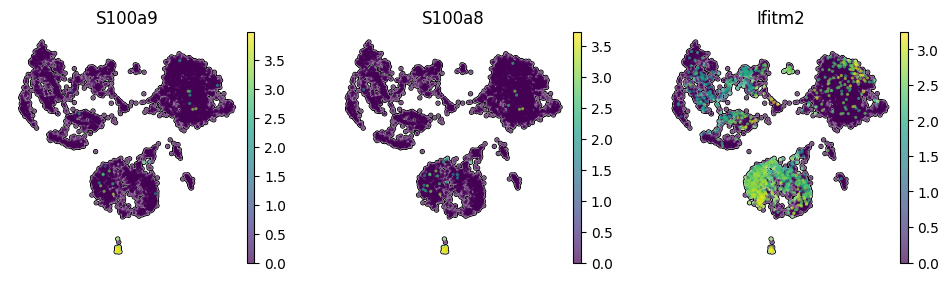

In [99]:
sc.pl.umap(adata, color=lupus_markers['neutrophil'], **umap_params)

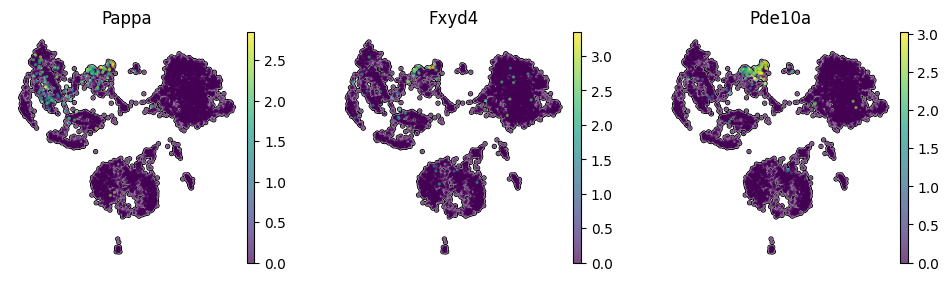

In [100]:
sc.pl.umap(adata, color=lupus_markers['collecting_duct'], **umap_params)

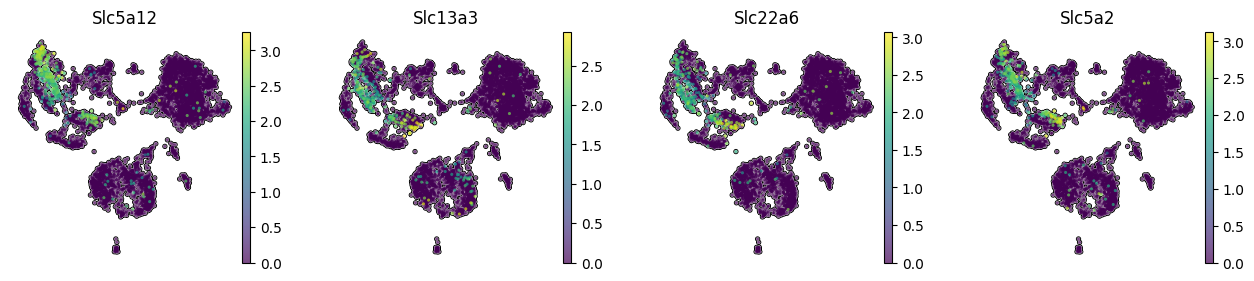

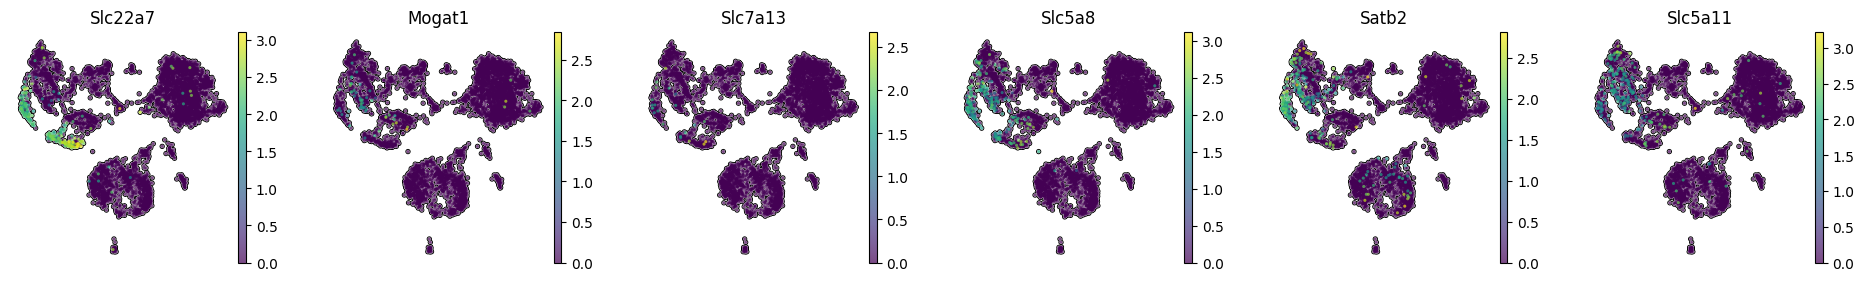

In [101]:
sc.pl.umap(adata, color=lupus_markers['proximal_tubule_S1S2'], **umap_params)
sc.pl.umap(adata, color=lupus_markers['proximal_tubule_S3'], **umap_params)

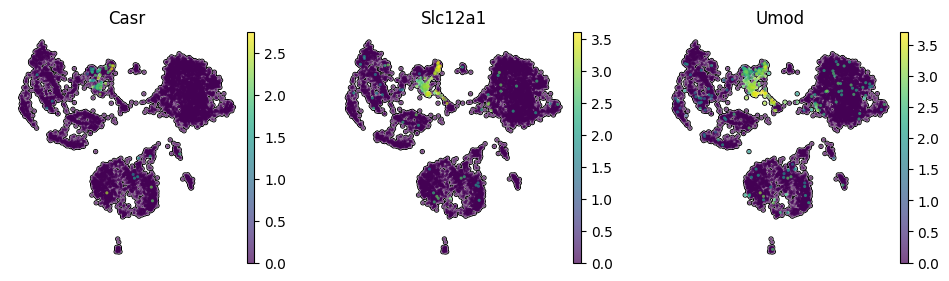

In [102]:
sc.pl.umap(adata, color=lupus_markers['henle_ascending_limb'], **umap_params)

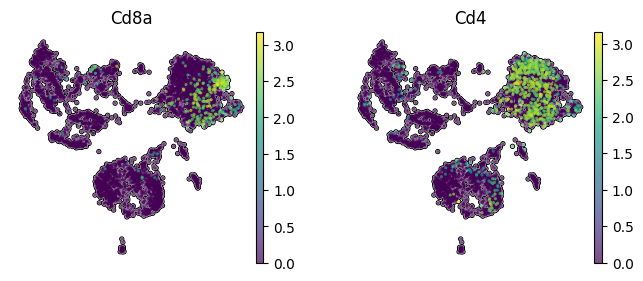

In [103]:
sc.pl.umap(adata, color=['Cd8a', 'Cd4'], **umap_params)

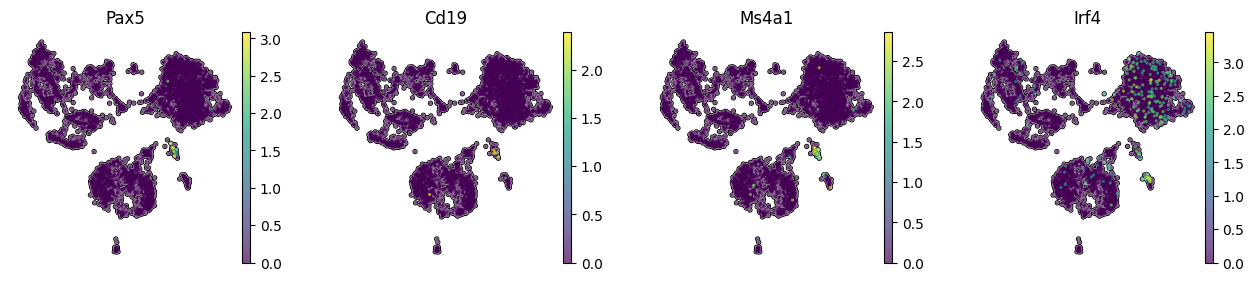

In [104]:
sc.pl.umap(adata, color=['Pax5', 'Cd19', 'Ms4a1', 'Irf4'], **umap_params)

In [105]:
annotations = {
    '0': 'CD4 T',
    '1': 'CD4 T',
    '2': 'Macrophage',
    '3': 'CD4 T',
    '4': 'CD8 T',
    '5': 'CD4 T',
    '6': 'CD8 T',
    '7': 'PT S1S2',
    '8': 'PT S3',
    '9': 'Loop of Henle',
    '10': 'DCT',
    '11': 'DCT',
    '12': 'Loop of Henle',
    '13': 'PT S1S2',
    '14': 'Macrophage',
    '15': 'Macrophage',
    '16': 'Plasma',
    '17': 'B',
    '18': 'Epithelial',
    '19': 'PT S3',
    '20': 'Neutrophil',
}

In [106]:
adata.obs['cell_type'] = adata.obs['leiden'].apply(lambda x: annotations[x])

KeyError: '21'

In [ ]:
plt.rcParams['figure.figsize'] = (9, 9)
plt.rcParams['figure.dpi'] = 300
sc.pl.umap(adata, color=['cell_type'], frameon=False, legend_loc='on data', s=100, 
           linewidth=0.1, edgecolor='black', 
           alpha=1, add_outline=False, 
        #    palette=color_dict, 
           title='', show=False)

plt.savefig('/tmp/aaaa.svg', dpi=300, format='svg', bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
sc.pl.umap(adata, color=['Ccl5', 'Cd74'], frameon=False, legend_loc='on data', s=100, 
           linewidth=0.1, edgecolor='black', 
           alpha=1, add_outline=False, show=False)

In [ ]:
%matplotlib inline

In [ ]:
xy_raw.index = adata.obs_names

In [ ]:
cells_xy = pd.concat(
    [
        xy_raw.x.apply(lambda x: df.index.get_loc(x) if x else None), 
        xy_raw.y.apply(lambda x: df.columns.get_loc(x) if x else None)
    ], axis=1
)

In [ ]:
adata_spatial = adata[cells_xy.dropna().index].copy()
adata_spatial.obsm['spatial'] = cells_xy.dropna().values

In [ ]:
# plt.rcParams['figure.figsize'] = (5, 5)
# plt.rcParams['figure.dpi'] = 200

# for i in adata_spatial.obs['cell_type'].unique():
#     sc.pl.embedding(
#         adata_spatial[adata_spatial.obs['cell_type'] == i],
#         color=['cell_type'],
#         frameon=False,
#         basis='spatial',
#         s=150,
#         title='',
#         alpha=0.5,
#     )
#     plt.show()

In [ ]:
from liana.method import cellphonedb, cellchat

In [ ]:
adata_spatial = adata_spatial[:, adata_spatial.var.feature_types == "Gene Expression"]

In [ ]:
from mousipy import translate

In [ ]:
adata_spatial_2 = translate(adata_spatial)

In [ ]:
cellphonedb(
    adata_spatial_2, 
    groupby="cell_type", 
    use_raw=False, 
    return_all_lrs=True, 
    verbose=True,
)

In [ ]:
import liana as li

In [ ]:
adata.obs['cell_type'].value_counts()

In [ ]:
immune_cells = [
    'CD4 T', 
    'Macrophage', 
    'Neutrophil',  
    'CD8 T', 
    'Plasma'
]

non_immune = [
    'Loop of Henle',
    'Epithelial',
    'DCT',
    'PT S3',
    'PT S1S2'
]

In [ ]:
li.pl.dotplot(
    adata=adata_spatial_2,
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,
    source_labels=immune_cells,
    target_labels=immune_cells,
    orderby="lr_means",
    orderby_ascending=False,
    top_n=20,
    figure_size=(14, 12),
    size_range=(1, 6),
)

In [ ]:
li.pl.dotplot(
    adata=adata_spatial_2,
    colour="lr_means",
    size="cellphone_pvals",
    inverse_size=True,
    source_labels=immune_cells,
    target_labels=non_immune,
    orderby="lr_means",
    orderby_ascending=False,
    top_n=20,
    figure_size=(14, 12),
    size_range=(1, 6),
)

In [ ]:
adata_spatial

In [ ]:
import matplotlib.patches as mpatches
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from io import BytesIO

# Compute cell type proportions per spot/location
cell_types = adata_spatial.obs['cell_type']
locations = adata_spatial.obsm['spatial']
df = adata_spatial.obs.copy()
df[['x', 'y']] = locations

# Group cell types by location (x, y rounded if float)
df['x_round'] = df['x'].round(2)
df['y_round'] = df['y'].round(2)
grouped = df.groupby(['x_round', 'y_round'])

celltype_categories = cell_types.astype('category').cat.categories
colors = plt.get_cmap('tab20').colors
celltype_color_dict = {ct: colors[i % len(colors)] for i, ct in enumerate(celltype_categories)}

fig, ax = plt.subplots(figsize=(8,8), dpi=200)
ax.set_aspect('equal')

# Plot background as faint points
ax.scatter(df['x_round'], df['y_round'], c='lightgrey', s=70, zorder=0, marker='s', alpha=0.1)

# Plot a pie chart at each location
def make_pie_image(proportions, colors, diameter=1.0):
    fig, pie_ax = plt.subplots(figsize=(diameter,diameter), dpi=100)
    pie_ax.pie(proportions, colors=colors, startangle=90, wedgeprops={'edgecolor':'none'})
    plt.axis('off')
    buf = BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0, transparent=True)
    plt.close(fig)
    buf.seek(0)
    return plt.imread(buf)

for (x, y), group in grouped:
    ct_counts = group['cell_type'].value_counts()
    proportions = []
    pie_colors = []
    for ct in celltype_categories:
        p = ct_counts[ct] if ct in ct_counts else 0
        proportions.append(p)
        pie_colors.append(celltype_color_dict[ct])
    sum_props = sum(proportions)
    if sum_props == 0:
        continue
    proportions = [p/sum_props for p in proportions]
    pie_img = make_pie_image(proportions, pie_colors, diameter=0.4)
    imagebox = OffsetImage(pie_img, zoom=0.3)
    ab = AnnotationBbox(imagebox, (x, y), frameon=False, pad=0)
    ax.add_artist(ab)

ax.set_xlabel('Spatial X')
ax.set_ylabel('Spatial Y')
# ax.set_title("Cell type proportions at each spatial location")

# Make legend
legend_patches = [mpatches.Patch(color=celltype_color_dict[ct], label=ct) for ct in celltype_categories]
ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
